# Terrain analysis from a DEM

Derive terrain products from an elevation raster:

- **`slope`** — steepness (degrees or percent).
- **`aspect`** — the compass direction a slope faces.
- **`hillshade`** — shaded relief for a given sun position.
- **`proximity`** — distance from each cell to the nearest target cell.

`slope` / `aspect` / `hillshade` return NumPy arrays; `proximity` returns a `Dataset`.

## Setup

In [1]:
%matplotlib inline

import tempfile
from pathlib import Path

import numpy as np

DATA = Path('../../../examples/data')
WORK = Path(tempfile.mkdtemp(prefix='pyramids-t2-'))
DATA.is_dir(), WORK.is_dir()

(True, True)

In [2]:
from pyramids.dataset import Dataset

dem = Dataset.read_file(DATA / 'dem' / 'DEM5km_Rhine_burned_acc.tif')
dem.shape, dem.epsg, dem.cell_size

((1, 125, 93), 4647, 5000.0)

The input elevation raster, drawn with the `terrain` colormap.

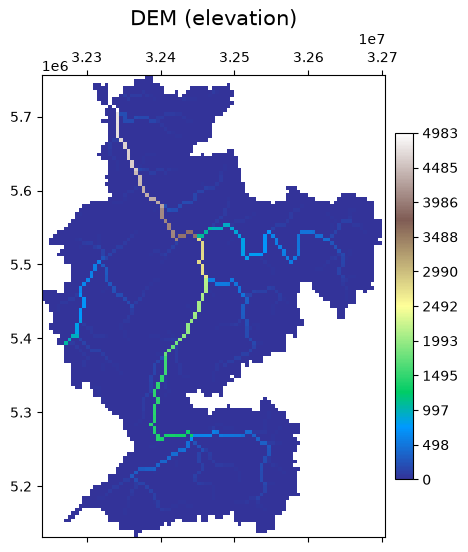

In [3]:
dem.plot(band=0, title="DEM (elevation)", cmap="terrain")

## Slope and aspect

`units='degrees'` (default) or `'percent'` for slope; aspect is in degrees.

In [4]:
slope = dem.slope(units='degrees')
aspect = dem.aspect()
slope.shape, float(np.nanmin(slope)), float(np.nanmax(slope)), aspect.shape

((125, 93), 0.0, 2147483647.0, (125, 93))

Slope returns a NumPy array — wrap it back into a `Dataset` matching the DEM's grid to plot it.
Steeper cells show up brighter.

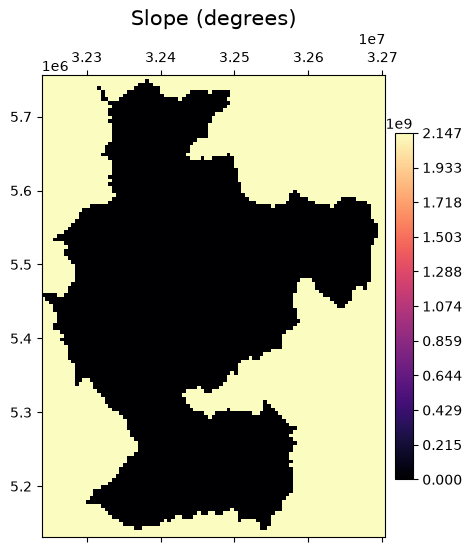

In [5]:
slope_ds = Dataset.create_from_array(
    slope, geo=dem.geotransform, epsg=dem.epsg, no_data_value=np.nan
)
slope_ds.plot(band=0, title="Slope (degrees)", cmap="magma")

## Hillshade

Shaded relief for a sun at `azimuth` (compass °) and `altitude` (° above horizon).

In [6]:
shade = dem.hillshade(azimuth=315.0, altitude=45.0)
shade.shape, float(np.nanmin(shade)), float(np.nanmax(shade))

((125, 93), 68.6872303218029, 2147483647.0)

Hillshade is a NumPy array too — wrapped into a `Dataset` and drawn in grayscale for classic
shaded relief (sun at NW, 45° above the horizon).

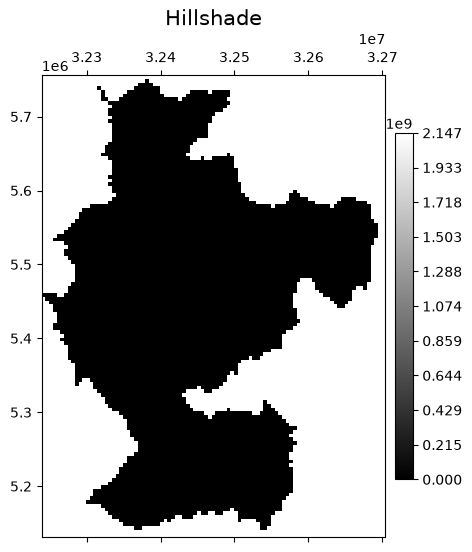

In [7]:
shade_ds = Dataset.create_from_array(
    shade, geo=dem.geotransform, epsg=dem.epsg, no_data_value=np.nan
)
shade_ds.plot(band=0, title="Hillshade", cmap="gray")

## Proximity

Euclidean distance from every cell to the nearest cell holding a target value (here, cells
equal to 1). Returns a `Dataset` whose values are distances in the raster's units (`GEO`).

In [8]:
dist = dem.proximity(target_values=[1], distance_units='GEO')
type(dist).__name__, dist.shape

('Dataset', (1, 125, 93))

Proximity returns a `Dataset` directly — each cell's value is its distance to the nearest
target cell, so values grow with distance from the targets.

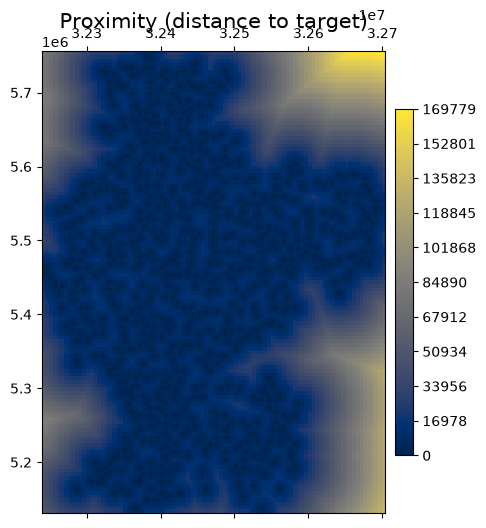

In [9]:
dist.plot(band=0, title="Proximity (distance to target)", cmap="cividis")

## Notes

- All of these also accept `chunks=` to run lazily on a Dask array — see the
  [Dask quickstart — Dataset](../dask/dataset.ipynb).
- To render a hillshade or slope, wrap the array back into a `Dataset` and use
  [Visualization](visualization.ipynb).